# AIAAIC Repository Exploration

## Setup and Load Cleaned Data

**Observations / what was fixed in cleaning data**
- The technology field has 241 unique values, but many are typos (e.g. "Facial recgnition", "Machine learnng", "Deepfak") or inconsistent casing. The ethics field has ~15 misspelling variants of its top terms. Fairness is split across 25+ subtypes by protected characteristic.
- Harm fields are severely undercoded. In 2023–2025, ~60% of incidents have no individual harm recorded. Societal harm coverage flipped in 2021 (from 23% → 57% → 76% by 2025) suggesting a methodology change, not an actual shift in harm patterns. Response rates have been falling — only 8% of 2024 incidents have a documented response. This means harm and response analyses are based on a minority of the dataset and likely biased toward more severe or well-documented incidents.


In [1]:
import re
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# ── Style ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#cccccc",
    "axes.grid":         True,
    "grid.color":        "#eeeeee",
    "grid.linewidth":    0.5,
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "figure.dpi":        130,
})
sns.set_palette("muted")

# ── Colour palette ─────────────────────────────────────────
PAL = {
    "blue":   "#2E6DB4",
    "purple": "#6B5DAD",
    "teal":   "#1A8A6A",
    "coral":  "#C9522F",
    "amber":  "#A66B17",
    "pink":   "#B84A6B",
    "gray":   "#71706B",
    "red":    "#C03E3E",
    "green":  "#4F8722",
}

print("✅ Setup complete")

✅ Setup complete


In [2]:
df = pd.read_csv("aiaaic_cleaned.csv")

# Cast boolean columns
bool_cols = [c for c in df.columns if c.startswith("is_") or c.startswith("has_")]
for c in bool_cols:
    df[c] = df[c].astype(bool)

print(f"Rows: {len(df)}  |  Columns: {len(df.columns)}")
print(f"Year range: {int(df['year'].min())}–{int(df['year'].max())}")
df.head(3)


Rows: 2243  |  Columns: 35
Year range: 2008–2026


,aiaaic_id,headline,occurred,deployer,developer,system_name,technology,purpose,news_trigger,ethical_issue,...,is_facial_recognition,is_deepfake,is_machine_learning,is_computer_vision,is_self_driving_system,is_agentic_ai,is_large_language_model,has_harm_data,has_developer,is_partial_year
0,AIAAIC2257,Welshman kills mother with sledgehammer after ...,2025,Tristan Roberts,DeepSeek Artificial Intelligence Co,DeepSeek,Generative AI,Research murder methods and weapon efficacy,Legal threat/action,Accountability; Anthropomorphism; Safety,...,False,False,False,False,False,False,False,True,True,False
1,AIAAIC2256,Google AI search summaries give cancer patient...,2024,NaN,Google,AI Overviews,Generative AI,Answer health and medical questions,Media investigation/fact check,Accuracy/reliability; Anthropomorphism; Consen...,...,False,False,False,False,False,False,False,True,True,False
2,AIAAIC2255,Meta AI agent leaks sensitive company and user...,2026,Meta Platforms,Meta Platforms,Meta AI agent,Agentic AI,Assist software engineers with technical queries,Media investigation/fact check,Accountability; Automation bias; Privacy/surve...,...,False,False,False,False,False,True,False,True,True,True


In [3]:
print(df.columns)

Index(['aiaaic_id', 'headline', 'occurred', 'deployer', 'developer',
       'system_name', 'technology', 'purpose', 'news_trigger', 'ethical_issue',
       'jurisdiction', 'sector', 'harm_individual', 'harm_societal',
       'harm_environmental', 'consequence', 'response', 'summary_link', 'year',
       'harm_breadth', 'has_consequence', 'has_response', 'detection_category',
       'fairness_subtypes', 'is_generative_ai', 'is_facial_recognition',
       'is_deepfake', 'is_machine_learning', 'is_computer_vision',
       'is_self_driving_system', 'is_agentic_ai', 'is_large_language_model',
       'has_harm_data', 'has_developer', 'is_partial_year'],
      dtype='str')


## Trends exploration 

### Incident volume over time

What is the big picture of AI incidents report in this database over time?

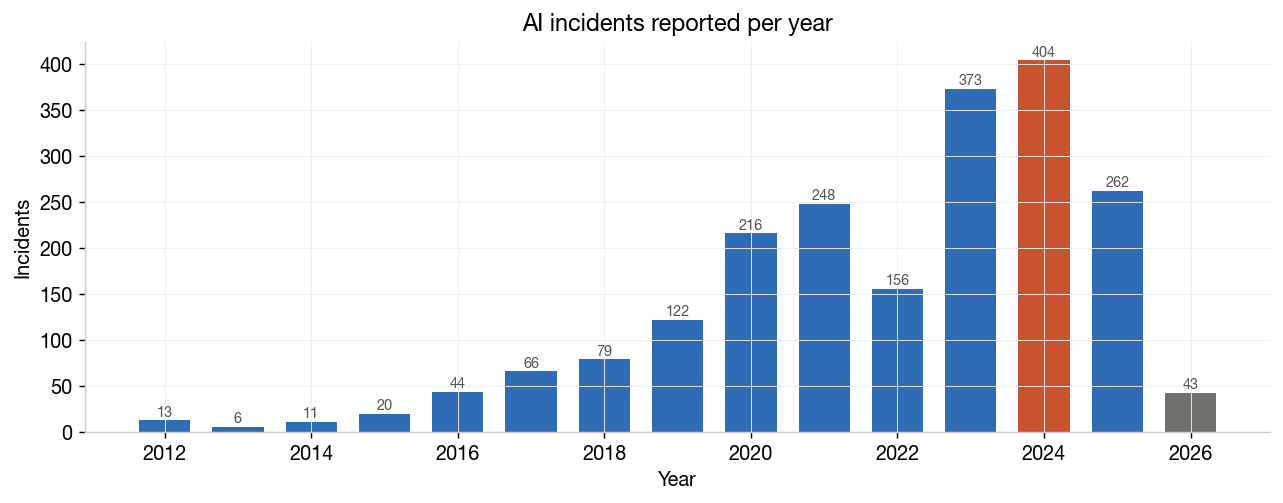

In [4]:
# helper
def tech_year_matrix(df, techs, year_range=range(2015, 2027)):
    """Build a year × technology count matrix."""
    mat = pd.DataFrame(0, index=list(year_range), columns=techs)
    for _, row in df[df["year"].isin(year_range)].iterrows():
        y = int(row["year"])
        for t in str(row["technology"]).split(";"):
            t = t.strip()
            if t in techs:
                mat.loc[y, t] += 1
    return mat

yearly = df[df["year"] >= 2012].groupby("year").size()

fig, ax = plt.subplots(figsize=(10, 4))

# highlighting the year with the most incidents 
colors = [PAL["coral"] if y == yearly.idxmax() else
          PAL["gray"] if y >= 2026 else PAL["blue"]
          for y in yearly.index]
ax.bar(yearly.index, yearly.values, color=colors, width=0.7)

# label number of incidents each year
for x, v in zip(yearly.index, yearly.values):
    ax.text(x, v + 4, str(v), ha="center", fontsize=8, color="#555")

ax.set(xlabel="Year", ylabel="Incidents", title="AI incidents reported per year")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** 
- Volume grew ~20× from 2015 (20) to 2024 (404). 
- The 2025 figure looks like a decline from 2024, but does this reflect ths reality of ai incidents landscape or could it be from reporting decline? AIAAIC is manually curated. To verify, we should cross-referencing with AIID and other databases

### Technology trends

Which technologies dominate the incident landscape, and how has that shifted?

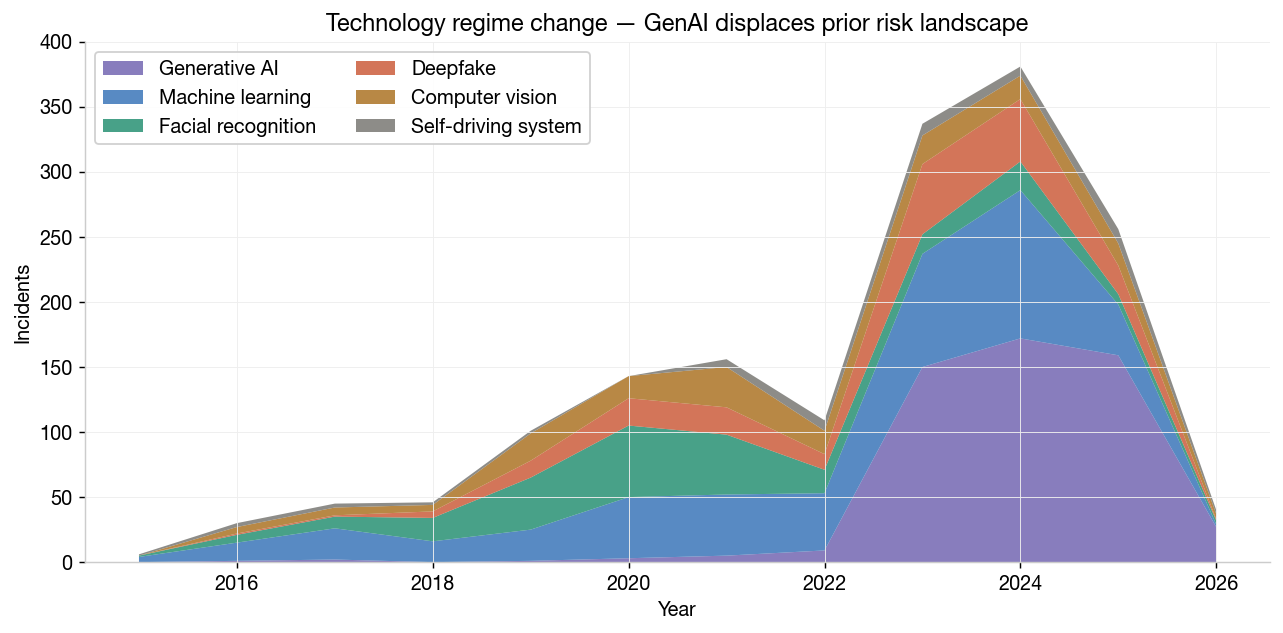

In [5]:
TECH_COLORS = {
    "Generative AI":       PAL["purple"],
    "Machine learning":    PAL["blue"],
    "Facial recognition":  PAL["teal"],
    "Deepfake":            PAL["coral"],
    "Computer vision":     PAL["amber"],
    "Self-driving system": PAL["gray"],
}
techs = list(TECH_COLORS.keys())
tmat = tech_year_matrix(df, techs)

fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(tmat.index, *[tmat[t] for t in techs],
             labels=techs, colors=[TECH_COLORS[t] for t in techs], alpha=0.8)
ax.legend(loc="upper left", framealpha=0.9, ncol=2)
ax.set(xlabel="Year", ylabel="Incidents",
       title="Technology regime change — GenAI displaces prior risk landscape")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** 
- GenAI went from near-zero (2022) to dominating the stack.
- Facial recognition peaked 2019–2021 then faded.

### GenAI Trends

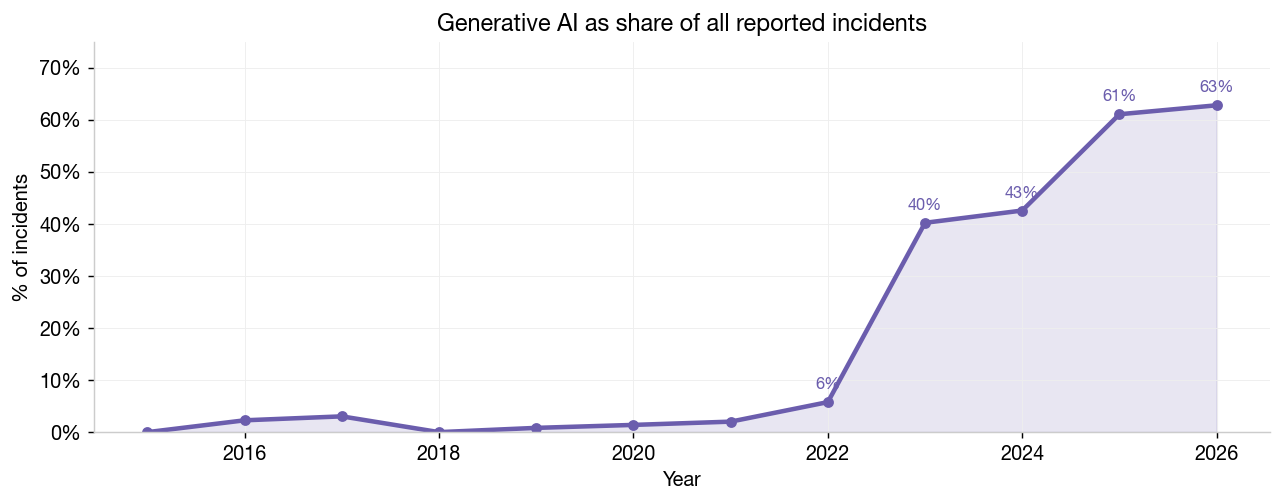

In [6]:
# get genai data
years = range(2015, 2027)
total = df[df["year"].isin(years)].groupby("year").size()
genai = df[df["year"].isin(years) & df["is_generative_ai"]].groupby("year").size()
pct = (genai / total * 100).fillna(0)

# line and color
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(pct.index, pct.values, alpha=0.15, color=PAL["purple"])
ax.plot(pct.index, pct.values, color=PAL["purple"], lw=2.5, marker="o", ms=5)

# plot each year percentage
for x, y in zip(pct.index, pct.values):
    if y > 5:
        ax.text(x, y + 2.5, f"{y:.0f}%", ha="center", fontsize=9, color=PAL["purple"])
# axis labels 
ax.set(xlabel="Year", ylabel="% of incidents",
       title="Generative AI as share of all reported incidents")
ax.set_ylim(0, 75)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** 6% in 2022 → 40% in 2023 → 61% in 2025. The is around when ChatGPT was released.

### Ethical concerns

How are these incidents categorized in ethics taxonomy? 

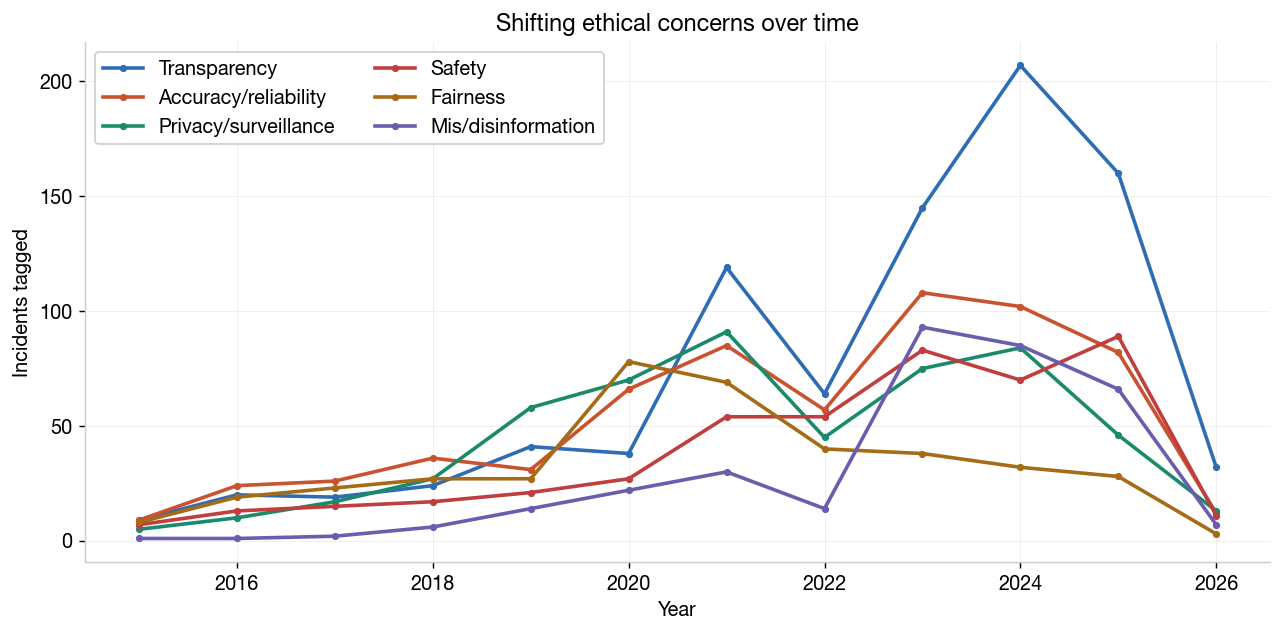

In [7]:
# helper function
def eth_year_matrix(df, issues, year_range=range(2015, 2027)):
    """Build a year × ethical issue count matrix."""
    mat = pd.DataFrame(0, index=list(year_range), columns=issues)
    for _, row in df[df["year"].isin(year_range)].iterrows():
        y = int(row["year"])
        for e in str(row["ethical_issue"]).split(";"):
            e = e.strip()
            if e in issues:
                mat.loc[y, e] += 1
    return mat


ETHICS_COLORS = {
    "Transparency":         PAL["blue"],
    "Accuracy/reliability": PAL["coral"],
    "Privacy/surveillance": PAL["teal"],
    "Safety":               PAL["red"],
    "Fairness":             PAL["amber"],
    "Mis/disinformation":   PAL["purple"],
}

issues = list(ETHICS_COLORS.keys())
emat = eth_year_matrix(df, issues)

fig, ax = plt.subplots(figsize=(10, 5))
for issue in issues:
    ax.plot(emat.index, emat[issue], color=ETHICS_COLORS[issue],
            lw=2, label=issue, marker="o", ms=3)

ax.legend(loc="upper left", framealpha=0.9, ncol=2)
ax.set(xlabel="Year", ylabel="Incidents tagged",
       title="Shifting ethical concerns over time")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** 
- Fairness dominated 2018–2021 (the algorithmic bias era). Is the decline real, or did it get reclassified into the 25+ fairness sub-categories?
- Misinformation exploded 6× from 2022→2023 with the rise of gen-ai and chatbots
- Transparency is the top concern in every year since 2021.



### Accountability

What are the accounability for AI incidents? How does it compare with the number of incidents? What are the trends? 

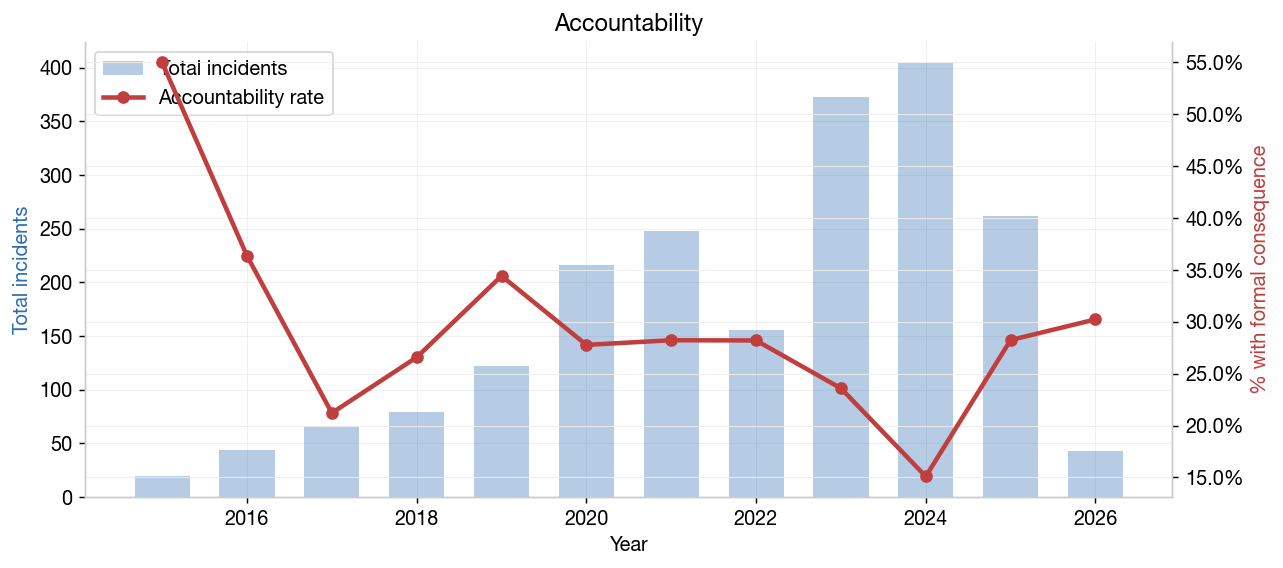

In [8]:
yrs = range(2015, 2027)
dfy = df[df["year"].isin(yrs)]
total_yr = dfy.groupby("year").size()
acct_yr = dfy.groupby("year")["has_consequence"].mean() * 100

# plotting first chart about total number
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(total_yr.index, total_yr.values, color=PAL["blue"], alpha=0.35,
        width=0.65, label="Total incidents", zorder=2)
ax1.set_ylabel("Total incidents", color=PAL["blue"])
ax1.set_xlabel("Year")

# plotting number of incidents that had consequence / were accounted for
ax2 = ax1.twinx()
ax2.plot(acct_yr.index, acct_yr.values, color=PAL["red"], lw=2.5,
         marker="o", ms=6, zorder=3, label="Accountability rate")
ax2.set_ylabel("% with formal consequence", color=PAL["red"])
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_title("Accountability")
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** 
- Accountability rate dropped from 55% (2015) to 15% (2024). Governance hasn't scaled with the problem.
- Is this also a lag in reporting, since accounting takes time.Consequence field completeness has also declined.

### What leads to consequence

Does severity or how an incident is discovered predict whether anything happens about it? What leads to consequences? 

In [9]:
# Per-tag consequence/response helper for multi-value categorical fields
def consequence_by_tag(df, col, min_n=20, top_n=None):
    """Explode a semicolon-delimited column and compute per-tag rates."""
    exploded = (
        df.assign(_tag=df[col].fillna("").str.split(r"\s*;\s*"))
          .explode("_tag")
          .query("_tag != ''")
    )
    g = exploded.groupby("_tag").agg(
        n=("has_consequence", "size"),
        consequence_rate=("has_consequence", "mean"),
        response_rate=("has_response", "mean"),
    )
    out = (g[g["n"] >= min_n]
           .assign(consequence_rate=lambda d: d["consequence_rate"] * 100,
                   response_rate=lambda d: d["response_rate"] * 100)
           .sort_values("consequence_rate", ascending=False)
           .reset_index()
           .rename(columns={"_tag": col}))
    return out.head(top_n) if top_n is not None else out


def plot_consequence_rates(rdf, col, title, figsize=(10, 6)):
    """Horizontal paired-bar chart matching the detection_category layout."""
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(rdf))
    w = 0.35
    ax.barh(x + w/2, rdf["consequence_rate"], w, color=PAL["red"], alpha=0.8, label="Has consequence")
    ax.barh(x - w/2, rdf["response_rate"], w, color=PAL["blue"], alpha=0.65, label="Has response")
    ax.set_yticks(x)
    ax.set_yticklabels([f'{r[col]}  (n={r["n"]})' for _, r in rdf.iterrows()])
    ax.set_xlabel("Rate (%)")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(loc="lower right")
    ax.set_title(title)
    ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


#### Detection method relation to consequence

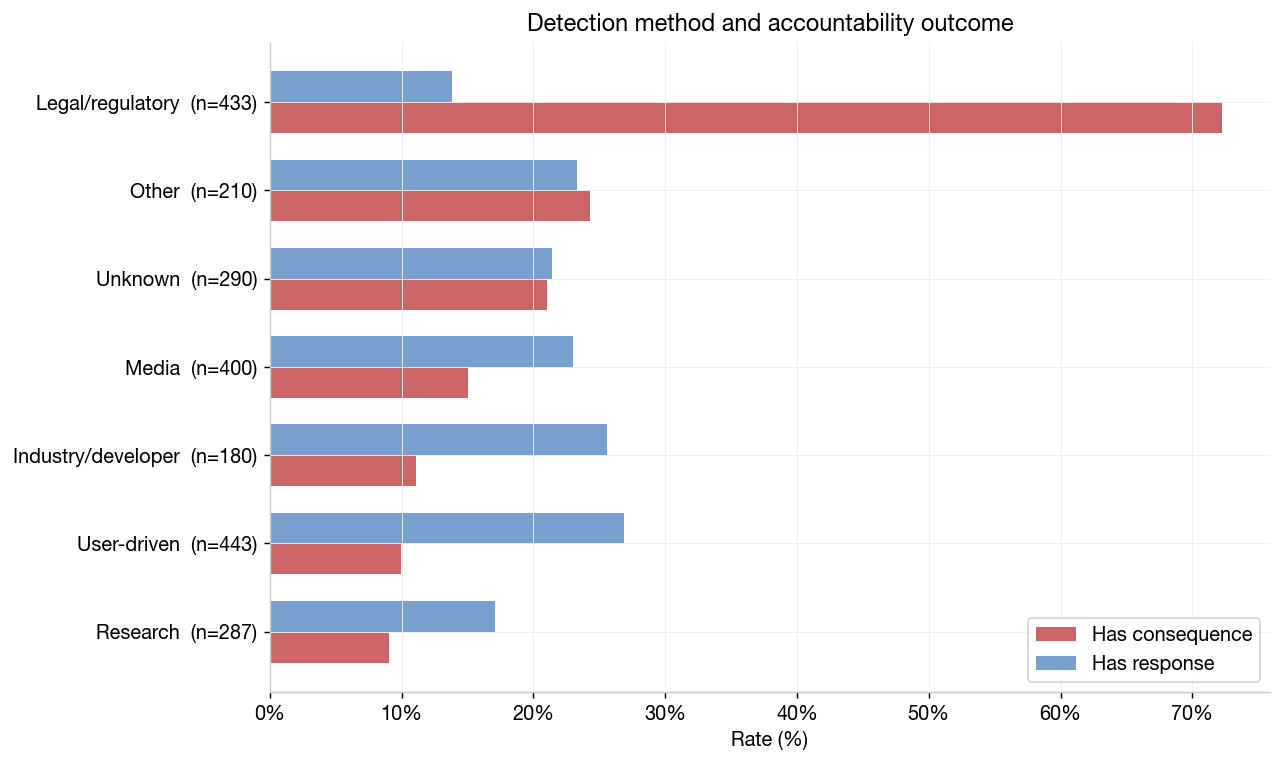

In [10]:
rdf = consequence_by_tag(df, "detection_category", min_n=30, top_n=12)
plot_consequence_rates(rdf, "detection_category",
                       "Detection method and accountability outcome")


**Observations:** 
- Legal/regulatory-triggered incidents have a 72% consequence rate vs 10% for user-reported and 8% for research-discovered. 
- who reports the problem is more predictive of outcome than how bad the problem is 

#### Sector

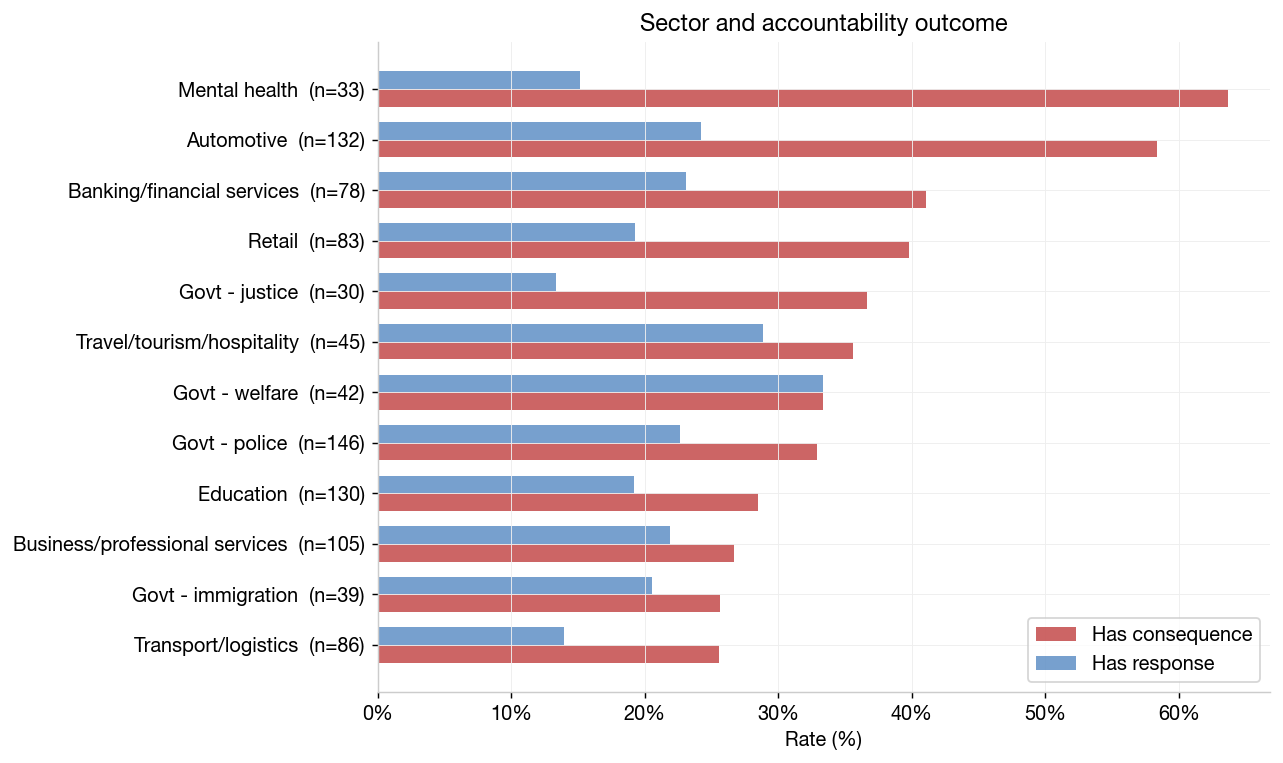

In [11]:
rdf = consequence_by_tag(df, "sector", min_n=30, top_n=12)
plot_consequence_rates(rdf, "sector",
                       "Sector and accountability outcome")


**Observation:** 
- For sectors, mental health has the biggest disparity, I have a suspicion that has to do with the rise of genai.
- Travel/Government/Education, Professional all has relatively high rate of response.
- Out of all the government related sectors, justice has the least response

#### Individual harm type

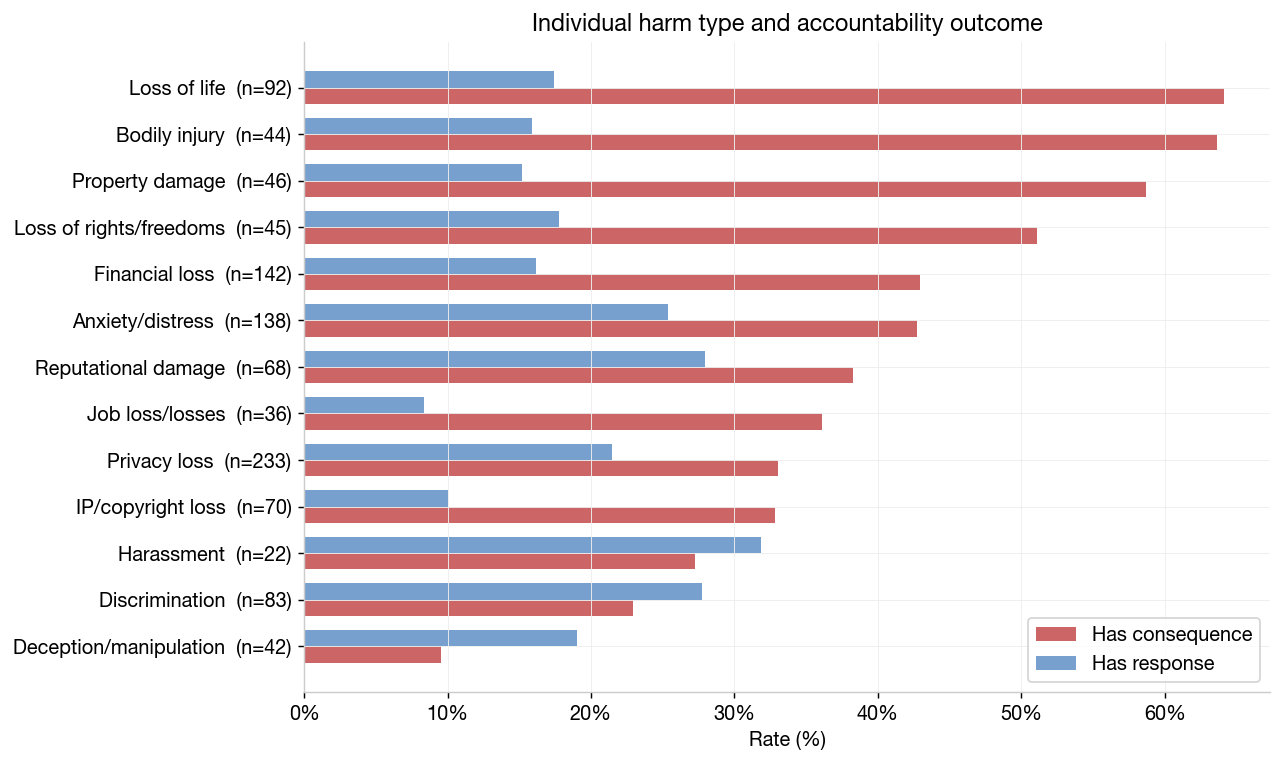

In [12]:
rdf = consequence_by_tag(df, "harm_individual", min_n=20)
plot_consequence_rates(rdf, "harm_individual",
                       "Individual harm type and accountability outcome")


**Observation:** 
- For the individual harm type, I am in shock that loss of life and bodily has the biggest disparity between consequence and response. This require more investigation.

#### Ethical issue

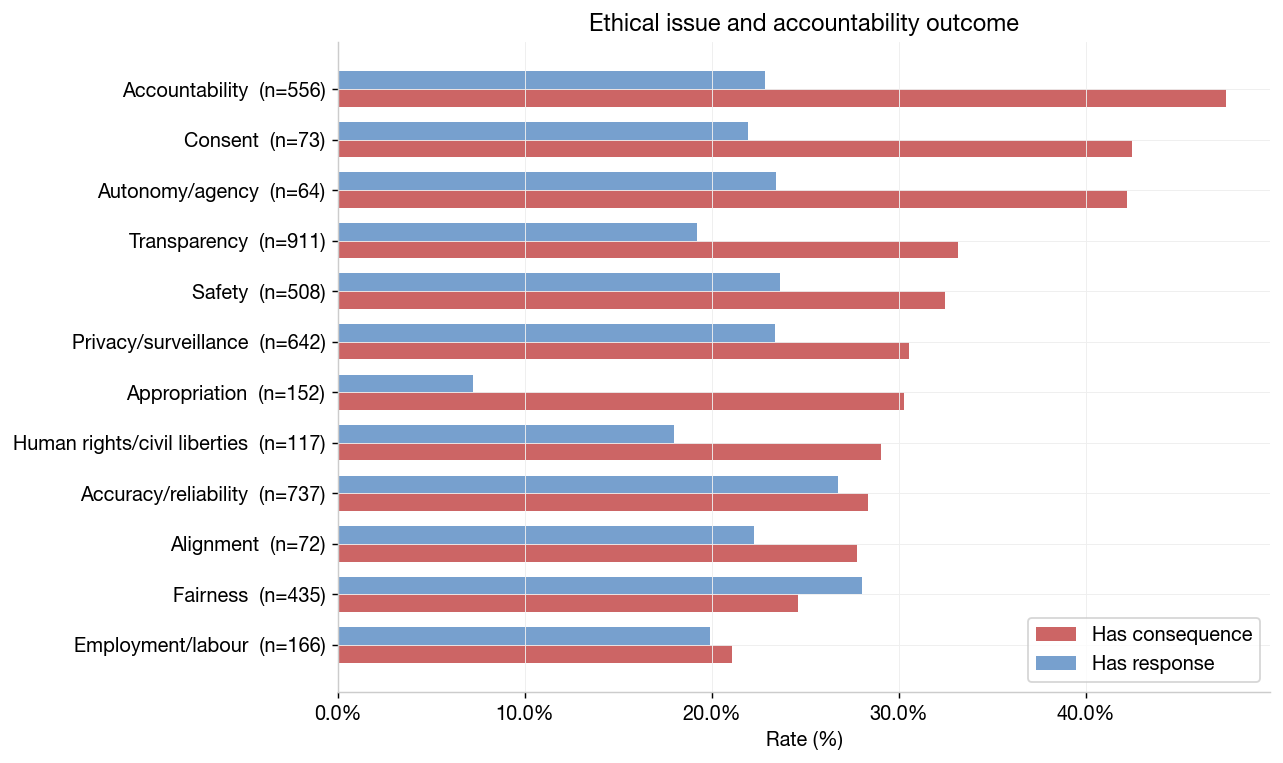

In [13]:
rdf = consequence_by_tag(df, "ethical_issue", min_n=50, top_n=12)
plot_consequence_rates(rdf, "ethical_issue",
                       "Ethical issue and accountability outcome")


### Developer risk profiles

Does each major AI company has a distinct failure bias? 

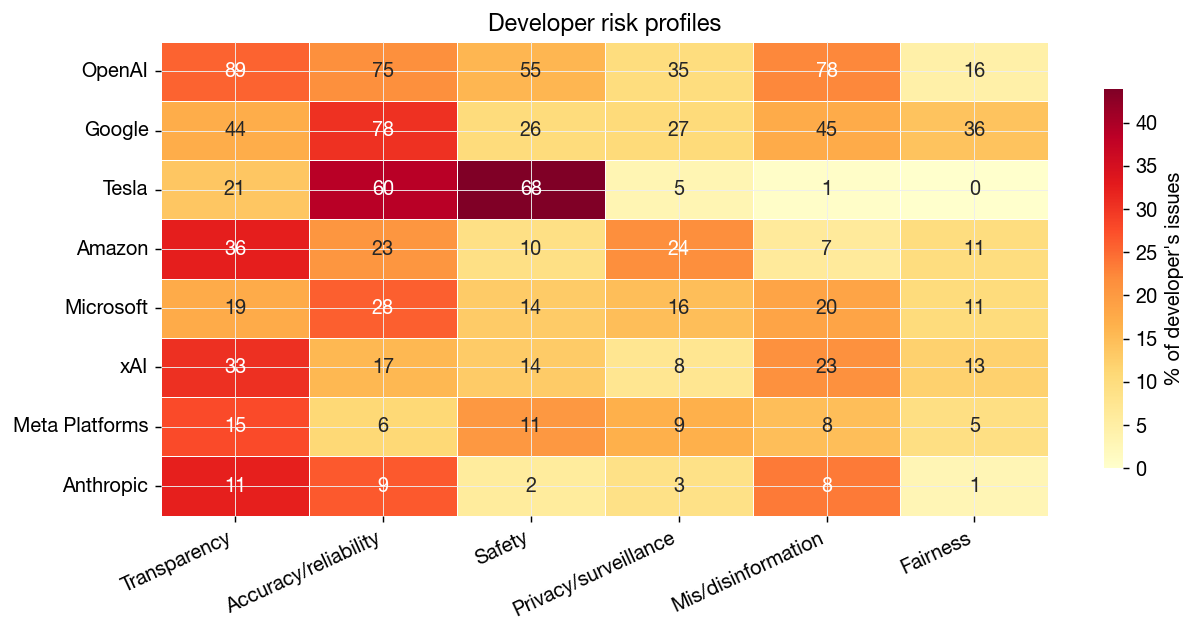

In [14]:
top_devs = ["OpenAI", "Google", "Tesla", "Amazon", "Microsoft", "xAI", "Meta Platforms", "Anthropic"]
top_ethics = ["Transparency", "Accuracy/reliability", "Safety",
              "Privacy/surveillance", "Mis/disinformation", "Fairness"]

matrix = pd.DataFrame(0, index=top_devs, columns=top_ethics)
for _, row in df.iterrows():
    devs = [d.strip() for d in str(row["developer"]).split(";")]
    issues = [e.strip() for e in str(row["ethical_issue"]).split(";")]
    for d in devs:
        if d in top_devs:
            for e in issues:
                if e in top_ethics:
                    matrix.loc[d, e] += 1

# Normalise per developer to show the PROFILE, not just volume
matrix_norm = matrix.div(matrix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(matrix_norm, annot=matrix.values, fmt="d",
            cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "% of developer's issues", "shrink": 0.8})
ax.set_title("Developer risk profiles")
ax.set_ylabel("")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

**Observation:** 
- Tesla's profile is dominated by safety (physical harm).
- OpenAI: transparency + misinformation. 
- Google: accuracy. 
- Amazon: privacy.

- Check whether the same developers show up with similar proportional profiles with AIID

### Developer accountability

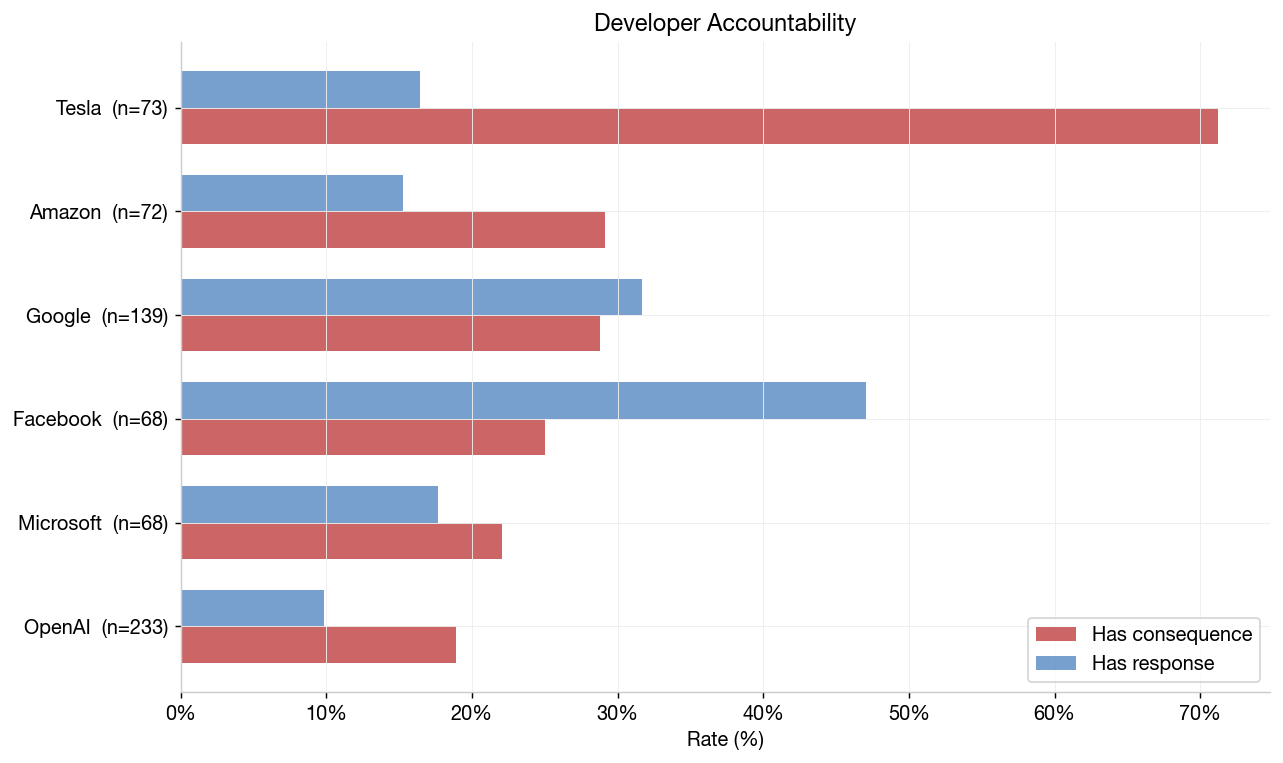

In [15]:
rdf = consequence_by_tag(df, "developer", min_n=50, top_n=12)
plot_consequence_rates(rdf, "developer",
                       "Developer Accountability")

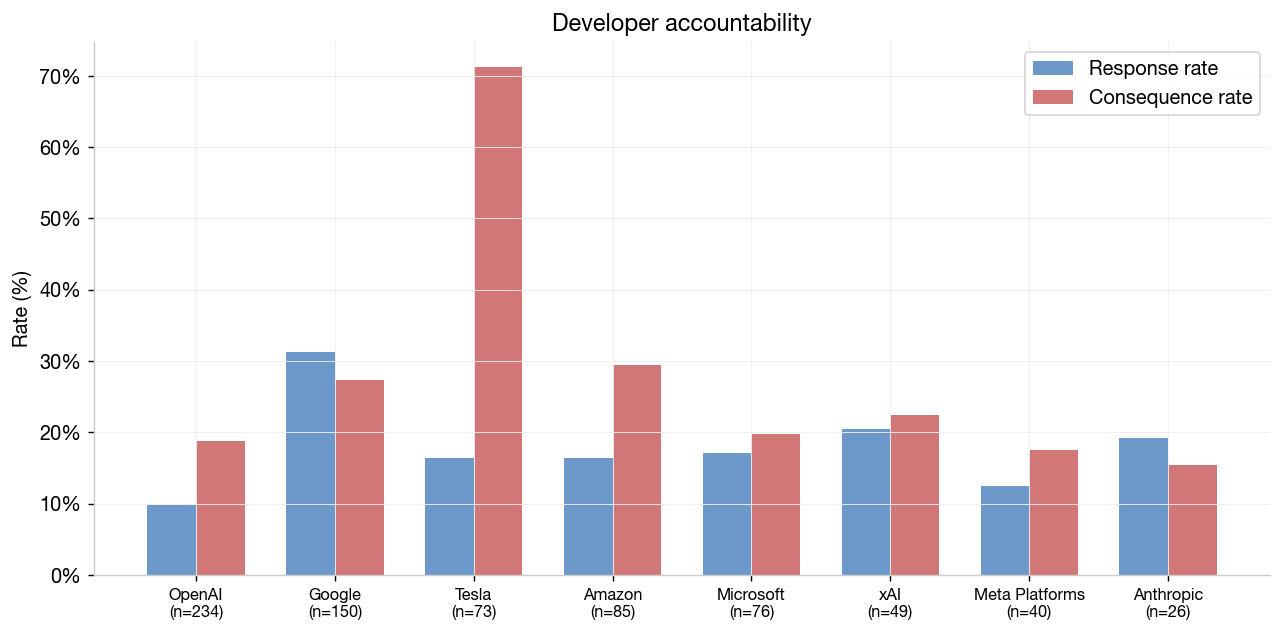

In [16]:
# rewriting for clarity
top_devs = ["OpenAI", "Google", "Tesla", "Amazon", "Microsoft", "xAI", "Meta Platforms", "Anthropic"]
rows = []
for dev in top_devs:
    sub = df[df["developer"].str.contains(re.escape(dev), na=False)]
    if len(sub) == 0:
        continue
    rows.append({
        "developer": dev, "n": len(sub),
        "response_rate": sub["has_response"].mean() * 100,
        "consequence_rate": sub["has_consequence"].mean() * 100,
    })
rdf = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rdf))
w = 0.35
ax.bar(x - w/2, rdf["response_rate"], w, color=PAL["blue"], alpha=0.7, label="Response rate")
ax.bar(x + w/2, rdf["consequence_rate"], w, color=PAL["red"], alpha=0.7, label="Consequence rate")
ax.set_xticks(x)
ax.set_xticklabels([f'{r["developer"]}\n(n={r["n"]})' for _, r in rdf.iterrows()], fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylabel("Rate (%)")
ax.legend()
ax.set_title("Developer accountability")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** 
- Tesla: 71% consequence rate (physical harm → litigation).
- OpenAI: 10% response rate across 234 incidents, the lowest
- Google responds most 31% but still faces consequences 27% of the time.

### Types of Harm by Technology

Different technologies produce different types of harm

In [17]:
# helpers

def split_field(series):
    """Explode a semicolon-delimited Series into a flat list."""
    items = []
    for val in series.dropna():
        for part in str(val).split(";"):
            p = part.strip()
            if p:
                items.append(p)
    return items

def count_field(series, top_n=10):
    """Count values in a semicolon-delimited field."""
    return pd.Series(Counter(split_field(series))).sort_values(ascending=False).head(top_n)

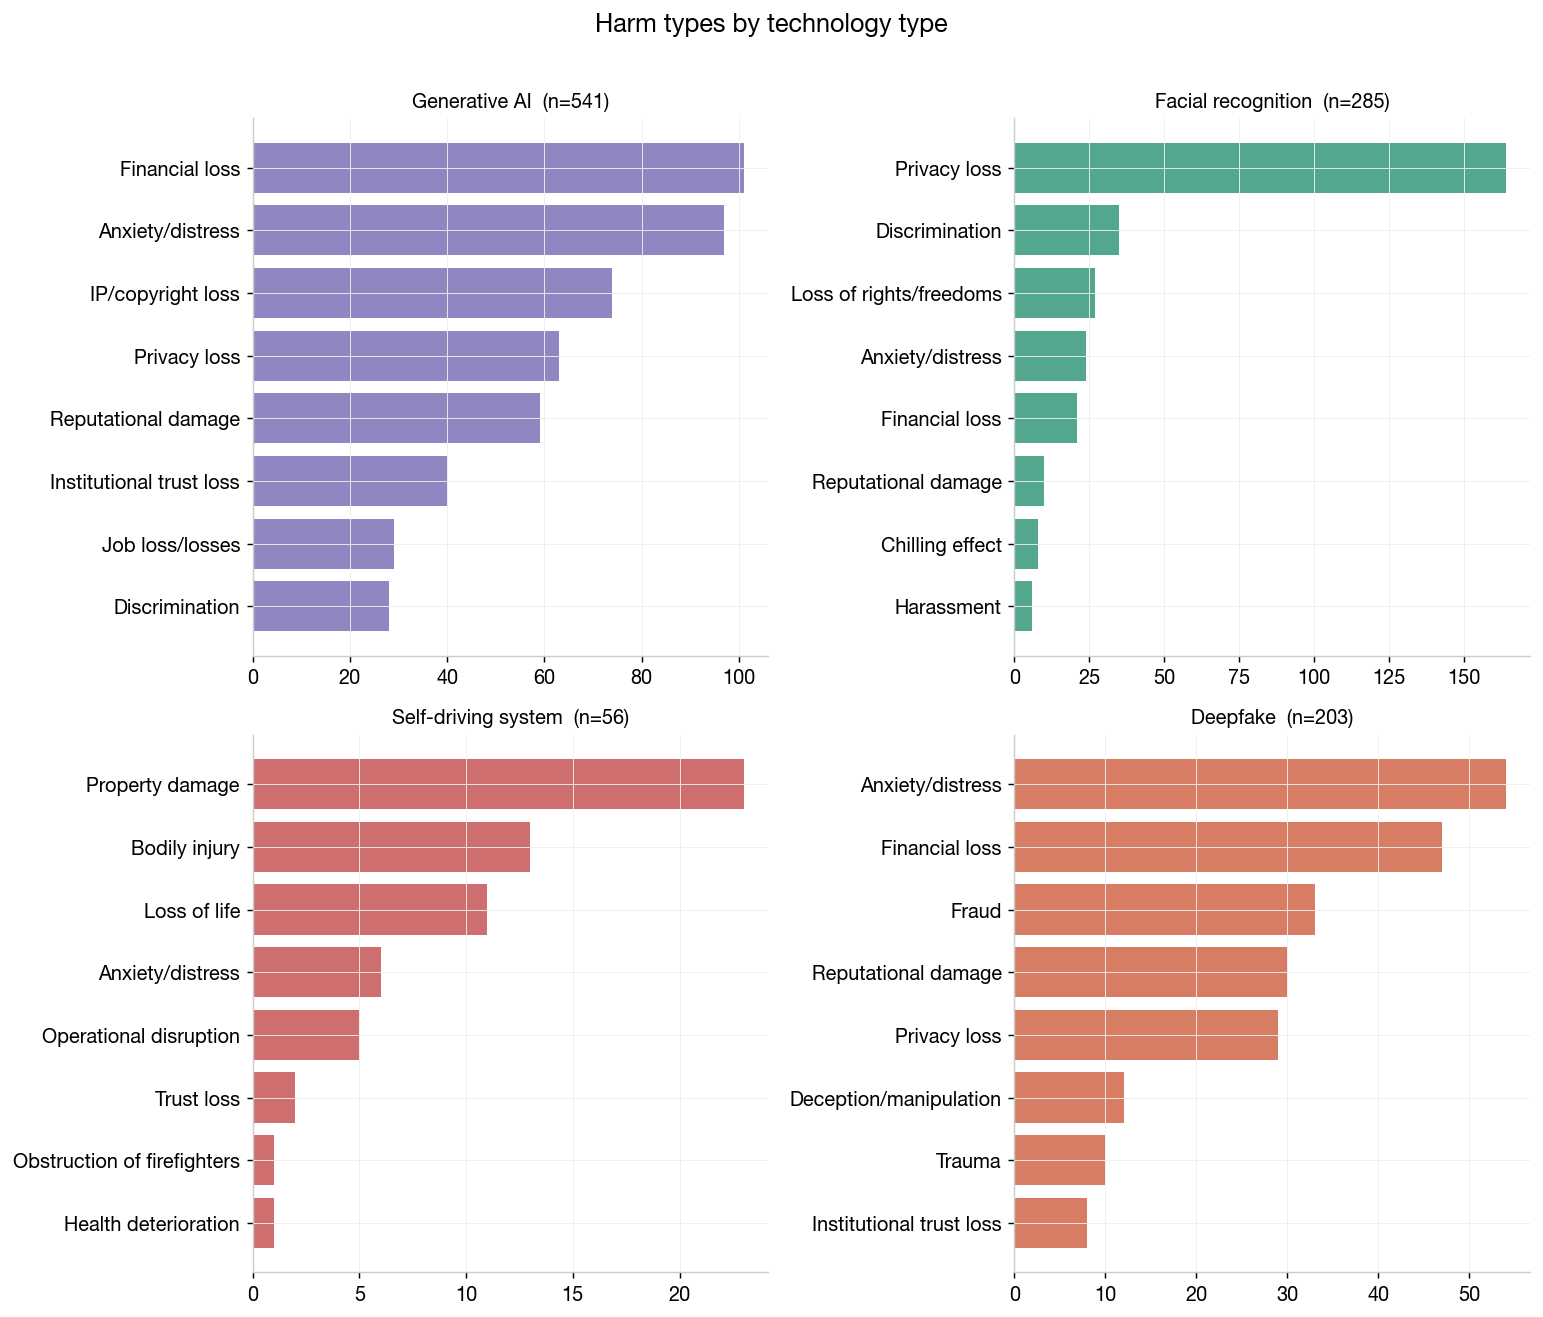

In [18]:
tech_groups = {
    "Generative AI":       "is_generative_ai",
    "Facial recognition":  "is_facial_recognition",
    "Self-driving system": "is_self_driving_system",
    "Deepfake":            "is_deepfake",
}
tech_cols = {
    "Generative AI": PAL["purple"],  "Facial recognition": PAL["teal"],
    "Self-driving system": PAL["red"], "Deepfake": PAL["coral"],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, (tech_name, col) in enumerate(tech_groups.items()):
    sub = df[df[col]]
    harms = split_field(sub["harm_individual"]) + split_field(sub["harm_societal"])
    counts = pd.Series(Counter(harms)).sort_values(ascending=True).tail(8)

    ax = axes.flat[idx]
    ax.barh(counts.index, counts.values, color=tech_cols[tech_name], alpha=0.75)
    ax.set_title(f"{tech_name}  (n={len(sub)})", fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Harm types by technology type", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Observation:** 
- **GenAI:** anxiety + IP/copyright + institutional trust loss 
- **Facial recognition:** privacy + loss of rights/freedoms civil liberties
- **Self-driving:** physical property damage, loss of life, bodily injury
- **Deepfake:** fraud + anxiety + reputational harm

### Fatal incidents

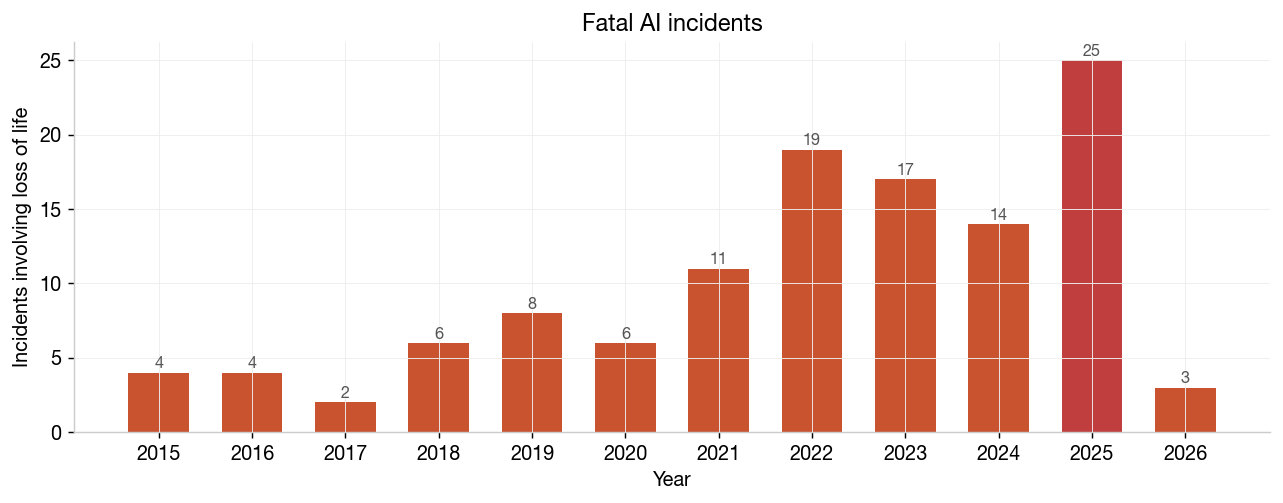

In [19]:
def has_loss_of_life(row):
    combined = str(row.get("harm_individual", "")) + ";" + str(row.get("harm_societal", ""))
    return "Loss of life" in combined

yrs = range(2015, 2027)
lol = df[df["year"].isin(yrs)]
lol_yr = lol[lol.apply(has_loss_of_life, axis=1)].groupby("year").size().reindex(yrs, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
colors = [PAL["red"] if v == lol_yr.max() else PAL["coral"] for v in lol_yr.values]
ax.bar(lol_yr.index, lol_yr.values, color=colors, width=0.65)
for x, v in zip(lol_yr.index, lol_yr.values):
    if v > 0:
        ax.text(x, v + 0.3, str(v), ha="center", fontsize=9, color="#555")

ax.set(xlabel="Year", ylabel="Incidents involving loss of life",
       title="Fatal AI incidents")
ax.set_xticks(list(yrs))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** 
- Fatal incidents hit 25 in 2025, the highest on record. Contributing factors? self-driving/driver assistance systems and GenAI-related incidents? 

## Summary of key narrative threads

| Thread | Finding | Confidence | Caveat |
|--------|---------|------------|--------|
| Volume growth | 20× from 2015→2024 | High | 2025 drop is reporting lag |
| GenAI takeover | 6% → 61% in 3 years | High | Stable taxonomy field |
| Ethical shift | Misinfo 6× in one year | High | Fairness decline may be reclassification |
| Accountability gap | 55% → 15% | Medium | Partially a coding gap |
| Detection → outcome | Legal=72%, User=10% | High | Strong structural finding |
| Developer profiles | Distinct per company | High | Cross-ref with AIID |
| Fatal incidents | Record 25 in 2025 | Medium | Harm field ~40% complete |

Trends to come back to
- Litigation volume is climbing (42 in 2025), but as a share of incidents it's flat — lawsuits haven't kept pace with incident growth. Regulatory investigations collapsed in 2024 (from 18 to 5), even as incidents peaked. Fines/settlements remain rare (3% overall). The system is getting busier, not more effective.
- I want to explore the accountability and detection gap more. Developer risk profile is also interesting, I would like to cross reference with the AAID database alter as well. I want to know more about their taxonomy, and trends within that.


## Limitations

1. Reporting lag. The 2024→2025 apparent "drop" (404 → 262) almost certainly reflects reporting lag since AIAAIC is manually curated. 2025 will likely revise upward. The 2026 figure (43 through May) is clearly incomplete. Need cross-references.

2. English-language, media-visible bias. 51% of incidents are USA. UK is #2. This reflects English-language media sourcing, not actual geographic distribution of AI harms. China, India, and Global South are structurally underrepresented.

3. Inconsistent coding over time. The individual↔societal harm split shifted around 2021 (societal coverage jumped from 23% to 57%). Cross-year harm comparisons might be unreliable. Response field completion dropped from 33% in 2019 to 8% in 2024. Ethics and technology fields are stable at ~99% coverage.

4. Taxonomy fragmentation. 241 technology values many one-offs and typos. Though I attempted to clean it, there still might be ones missed.

5. Detection bias. User complaints and media investigations surface 47% of incidents, meaning this dataset could be potentially over-representing visible, consumer-facing harms and under-represents harms to communities with less media access or digital literacy.


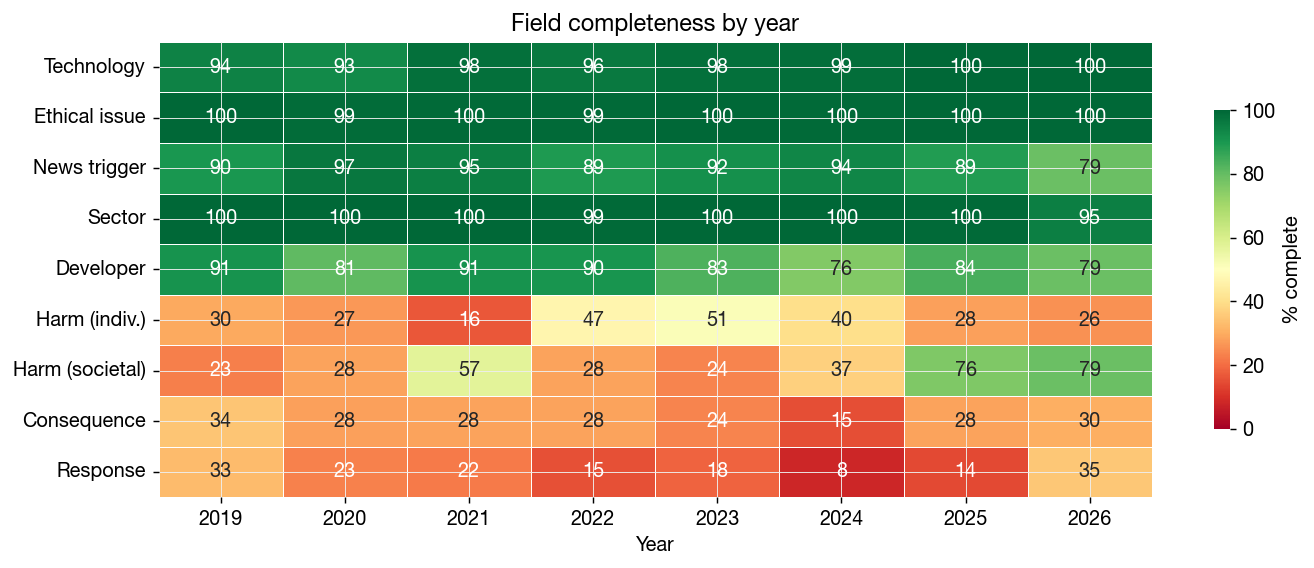

In [20]:
yrs = range(2019, 2027)
fields = ["technology", "ethical_issue", "news_trigger", "sector",
          "developer", "harm_individual", "harm_societal", "consequence", "response"]
labels = ["Technology", "Ethical issue", "News trigger", "Sector",
          "Developer", "Harm (indiv.)", "Harm (societal)", "Consequence", "Response"]

matrix = pd.DataFrame(index=[str(y) for y in yrs], columns=labels, dtype=float)
for y in yrs:
    sub = df[df["year"] == y]
    n = len(sub)
    if n == 0:
        continue
    for f, fl in zip(fields, labels):
        col = sub[f]
        filled = (col.notna() & (col.astype(str).str.strip() != "")).sum()
        matrix.loc[str(y), fl] = round(filled / n * 100, 1)

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(matrix.astype(float).T, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=0, vmax=100, linewidths=0.5, ax=ax,
            cbar_kws={"label": "% complete", "shrink": 0.7})
ax.set_title("Field completeness by year")
ax.set_xlabel("Year")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

#### Data quality by response completion
- **Response field** dropped to 8% in 2024. Any response-based analysis in recent years is based on a tiny minority of incidents.
- **Harm (individual)** hovers 25–50%; **harm (societal)** jumped to 76–79% in 2025–2026, suggesting a coding methodology shift around 2021.
- **Technology** and **ethical issue** are stable at ~99% — safe for trend analysis.
- The accountability gap finding is substantial, as consequence field is ~15–30%, but part of it could be coding lag rather than true absence of consequences.